# M4A2 - GANs

Na prática de hoje vamos treinar um modelo do tipo GAN utilizando [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Treinar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

In [3]:
batch_size = 100

# MNIST Dataset.
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))])

train_dataset = torchvision.datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
# Data Loader.
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.73MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 164kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 949kB/s]


## Treinar Modelo

Agora vamos criar os modelos e treinar ele.

In [4]:
########################
## Criando os modelos ##
########################


# Gerador.
class Generator(torch.nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()       
        self.fc1 = torch.nn.Linear(g_input_dim, 256)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, g_output_dim)
    
    # método forward. 
    def forward(self, x): 
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))

# Discrimador.
class Discriminator(torch.nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(d_input_dim, 1024)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, 1)
    
    # método forward. 
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        return torch.sigmoid(self.fc4(x))

In [5]:
# Instanciar as redes.
z_dim = 100
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

/Users/larry/Library/Python/3.9/lib/python/site-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [6]:
# Função de perda.
criterion = torch.nn.BCELoss() 

# Otimizador.
lr = 0.0002 
G_optimizer = torch.optim.Adam(G.parameters(), lr = lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr = lr)


In [7]:
def D_train(x):
    #=======================Treino do discriminador=======================#
    D.zero_grad()

    # Treina discriminador em dados reais.
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(batch_size, 1)
    x_real, y_real = torch.autograd.Variable(x_real.to(device)), torch.autograd.Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # Treina discriminador em dados falsos.
    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    x_fake, y_fake = G(z), torch.autograd.Variable(torch.zeros(batch_size, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # Backpropagation e otimização dos parâmetros do discriminador.
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()
        
    return  D_loss.data.item()

def G_train(x):
    #=======================Treino do gerador=======================#
    G.zero_grad()

    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    y = torch.autograd.Variable(torch.ones(batch_size, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # Backpropagation e otimização dos parâmetros do gerador.
    G_loss.backward()
    G_optimizer.step()
        
    return G_loss.data.item()

In [8]:
# Laço de treino.
n_epoch = 200
for epoch in range(1, n_epoch+1):           
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        G_losses.append(G_train(x))

    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            (epoch), n_epoch, torch.mean(torch.FloatTensor(D_losses)), torch.mean(torch.FloatTensor(G_losses))))

[1/200]: loss_d: 0.559, loss_g: 6.174
[2/200]: loss_d: 0.134, loss_g: 12.380
[3/200]: loss_d: 0.481, loss_g: 7.636
[4/200]: loss_d: 0.421, loss_g: 3.801
[5/200]: loss_d: 0.251, loss_g: 5.100
[6/200]: loss_d: 0.299, loss_g: 4.858
[7/200]: loss_d: 0.387, loss_g: 3.977
[8/200]: loss_d: 0.409, loss_g: 3.638
[9/200]: loss_d: 0.469, loss_g: 3.262
[10/200]: loss_d: 0.499, loss_g: 2.994
[11/200]: loss_d: 0.506, loss_g: 2.901
[12/200]: loss_d: 0.584, loss_g: 2.554
[13/200]: loss_d: 0.621, loss_g: 2.464
[14/200]: loss_d: 0.605, loss_g: 2.520
[15/200]: loss_d: 0.710, loss_g: 2.133
[16/200]: loss_d: 0.712, loss_g: 2.151
[17/200]: loss_d: 0.761, loss_g: 2.058
[18/200]: loss_d: 0.752, loss_g: 2.034
[19/200]: loss_d: 0.778, loss_g: 1.959
[20/200]: loss_d: 0.823, loss_g: 1.812
[21/200]: loss_d: 0.845, loss_g: 1.764
[22/200]: loss_d: 0.887, loss_g: 1.669
[23/200]: loss_d: 0.897, loss_g: 1.650
[24/200]: loss_d: 0.891, loss_g: 1.656
[25/200]: loss_d: 0.936, loss_g: 1.566
[26/200]: loss_d: 0.958, loss_g: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


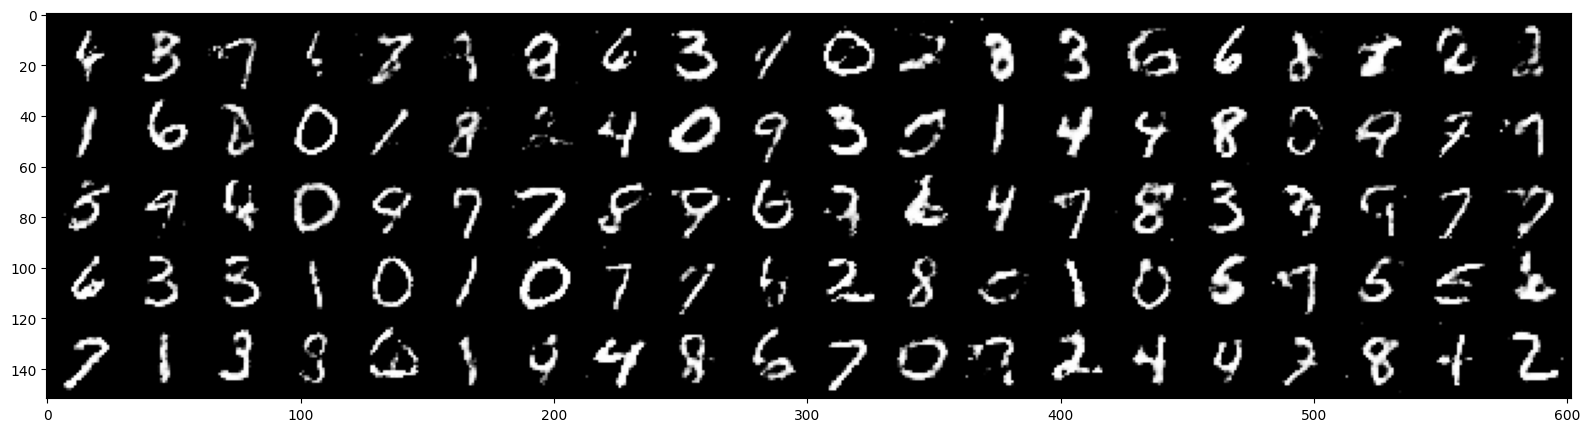

In [9]:
# Inferência com modelo treinado.
with torch.no_grad():
    test_z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    generated = G(test_z)

generated = generated.view(generated.size(0), 1, 28, 28)
grid = torchvision.utils.make_grid(generated.cpu(), 20)
grid = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.imshow(grid.squeeze(), cmap='gray')


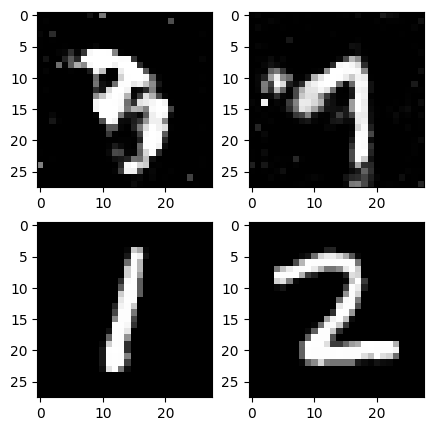

In [10]:
# Comparação resultados dos modelos e dados da base.
indexes_gen = [np.random.randint(0, batch_size), np.random.randint(0, batch_size)]
indexes_data = [np.random.randint(0, len(train_dataset)), np.random.randint(0, len(train_dataset))]

index = 0

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
axes[0, 0].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[0]].transpose(1, 2, 0), cmap="gray")
axes[0, 1].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[1]].transpose(1, 2, 0), cmap="gray")
axes[1, 0].imshow(train_dataset[indexes_data[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1, 1].imshow(train_dataset[indexes_data[1]][0].numpy().transpose(1,2,0), cmap="gray")

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/lyeoni/pytorch-mnist-GAN
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [x] Tente alterar a base de dados e veja se o modelo continua funcionando?
- [x] Tente alterar alguns hiperparâmetros de treinamento, como learning rate, batch, e veja como isso altera os resultados.

### Atividade 1 — Trocando a base de dados

Aqui vou tentar usar o **FashionMNIST** em vez do MNIST. Como as imagens também são 28x28, não precisa mexer na arquitetura do modelo, só na fonte dos dados.

In [11]:
# Atividade 1: FashionMNIST no lugar do MNIST
# FashionMNIST tem o mesmo shape (28x28 grayscale), então o modelo não precisa mudar

batch_size_ac1 = 100

transform_ac1 = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))])

train_dataset_ac1 = torchvision.datasets.FashionMNIST(
    root='./fashion_data/', train=True, transform=transform_ac1, download=True)
train_loader_ac1 = torch.utils.data.DataLoader(
    dataset=train_dataset_ac1, batch_size=batch_size_ac1, shuffle=True, num_workers=0)

print(f'Dataset: {len(train_dataset_ac1)} imagens')
print(f'Classes: {train_dataset_ac1.classes}')


100%|██████████| 26.4M/26.4M [00:04<00:00, 5.66MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 96.9kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.33MB/s]

Dataset: 60000 imagens
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [12]:
# Recria os modelos do zero pra treinar no FashionMNIST
fashion_dim = train_dataset_ac1.data.size(1) * train_dataset_ac1.data.size(2)

G_fashion = Generator(g_input_dim=z_dim, g_output_dim=fashion_dim).to(device)
D_fashion = Discriminator(fashion_dim).to(device)

criterion_ac1 = torch.nn.BCELoss()
G_opt_ac1 = torch.optim.Adam(G_fashion.parameters(), lr=0.0002)
D_opt_ac1 = torch.optim.Adam(D_fashion.parameters(), lr=0.0002)

def D_train_fashion(x):
    D_fashion.zero_grad()
    x_real = x.view(-1, fashion_dim).to(device)
    y_real = torch.ones(x_real.size(0), 1).to(device)
    D_output = D_fashion(x_real)
    D_real_loss = criterion_ac1(D_output, y_real)

    z = torch.randn(x_real.size(0), z_dim).to(device)
    x_fake = G_fashion(z)
    y_fake = torch.zeros(x_real.size(0), 1).to(device)
    D_output = D_fashion(x_fake)
    D_fake_loss = criterion_ac1(D_output, y_fake)

    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_opt_ac1.step()
    return D_loss.data.item()

def G_train_fashion(x):
    G_fashion.zero_grad()
    z = torch.randn(x.size(0), z_dim).to(device)
    y = torch.ones(x.size(0), 1).to(device)
    G_output = G_fashion(z)
    D_output = D_fashion(G_output)
    G_loss = criterion_ac1(D_output, y)
    G_loss.backward()
    G_opt_ac1.step()
    return G_loss.data.item()

n_epoch_ac1 = 50
for epoch in range(1, n_epoch_ac1 + 1):
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader_ac1):
        D_losses.append(D_train_fashion(x))
        G_losses.append(G_train_fashion(x))
    if epoch % 10 == 0:
        print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            epoch, n_epoch_ac1,
            torch.mean(torch.FloatTensor(D_losses)),
            torch.mean(torch.FloatTensor(G_losses))))


[10/50]: loss_d: 0.787, loss_g: 1.965
[20/50]: loss_d: 0.932, loss_g: 1.528
[30/50]: loss_d: 0.990, loss_g: 1.350
[40/50]: loss_d: 1.014, loss_g: 1.313
[50/50]: loss_d: 1.059, loss_g: 1.230


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9999987].


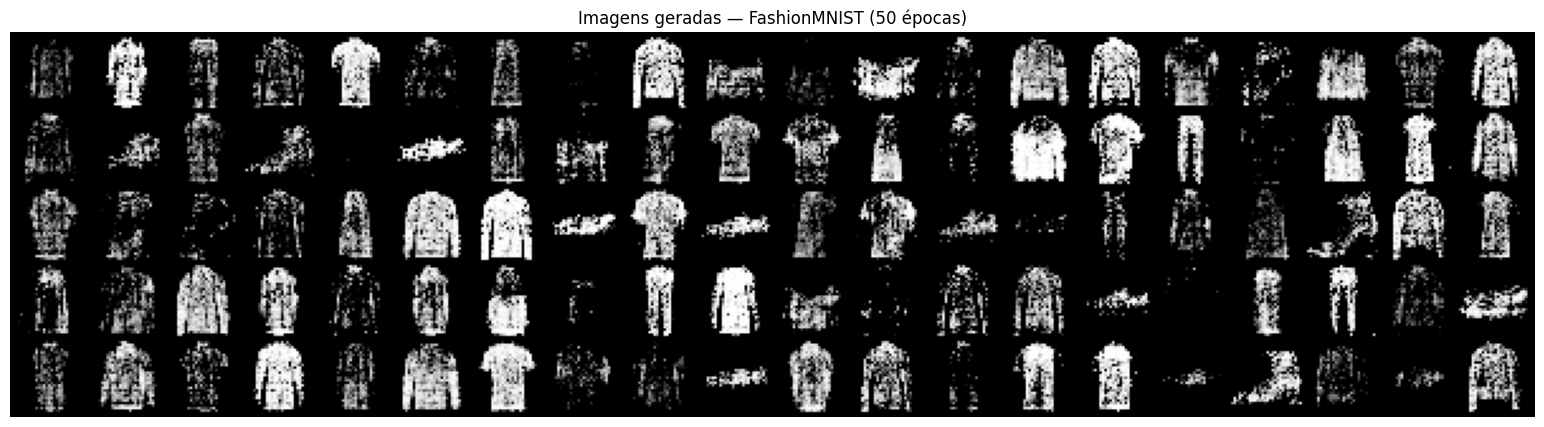

In [13]:
# Visualiza o que o gerador aprendeu com o FashionMNIST
with torch.no_grad():
    test_z = torch.randn(batch_size_ac1, z_dim).to(device)
    generated_fashion = G_fashion(test_z)

generated_fashion = generated_fashion.view(generated_fashion.size(0), 1, 28, 28)
grid_fashion = torchvision.utils.make_grid(generated_fashion.cpu(), 20)
grid_fashion = grid_fashion.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.title('Imagens geradas — FashionMNIST (50 épocas)')
plt.imshow(grid_fashion.squeeze(), cmap='gray')
plt.axis('off')
plt.show()


### Conclusão

O treinamento com FashionMNIST por 50 épocas com `lr=0.0002` e `batch_size=100` 
produziu resultados visivelmente superiores ao experimento anterior. O gerador 
conseguiu capturar a estrutura geral das peças de roupa — silhuetas de camisetas, 
calças e casacos são reconhecíveis na maioria das imagens geradas.

## Atividade 2 — Mexendo nos hiperparâmetros

Agora vou testar com um **learning rate maior** (`0.001` vs `0.0002`) e um **batch menor** (`64` vs `100`) pra ver se o treinamento fica mais instável ou mais rápido.

In [14]:
# Atividade 2: lr mais alto e batch menor
batch_size_ac2 = 64
lr_ac2 = 0.001

train_loader_ac2 = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size_ac2, shuffle=True, num_workers=0)

G2 = Generator(g_input_dim=z_dim, g_output_dim=mnist_dim).to(device)
D2 = Discriminator(mnist_dim).to(device)

criterion_ac2 = torch.nn.BCELoss()
G_opt_ac2 = torch.optim.Adam(G2.parameters(), lr=lr_ac2)
D_opt_ac2 = torch.optim.Adam(D2.parameters(), lr=lr_ac2)

def D_train_ac2(x):
    D2.zero_grad()
    x_real = x.view(-1, mnist_dim).to(device)
    y_real = torch.ones(x_real.size(0), 1).to(device)
    D_output = D2(x_real)
    D_real_loss = criterion_ac2(D_output, y_real)

    z = torch.randn(x_real.size(0), z_dim).to(device)
    x_fake = G2(z)
    y_fake = torch.zeros(x_real.size(0), 1).to(device)
    D_output = D2(x_fake)
    D_fake_loss = criterion_ac2(D_output, y_fake)

    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_opt_ac2.step()
    return D_loss.data.item()

def G_train_ac2(x):
    G2.zero_grad()
    z = torch.randn(x.size(0), z_dim).to(device)
    y = torch.ones(x.size(0), 1).to(device)
    G_output = G2(z)
    D_output = D2(G_output)
    G_loss = criterion_ac2(D_output, y)
    G_loss.backward()
    G_opt_ac2.step()
    return G_loss.data.item()

n_epoch_ac2 = 50
for epoch in range(1, n_epoch_ac2 + 1):
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader_ac2):
        D_losses.append(D_train_ac2(x))
        G_losses.append(G_train_ac2(x))
    if epoch % 10 == 0:
        print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            epoch, n_epoch_ac2,
            torch.mean(torch.FloatTensor(D_losses)),
            torch.mean(torch.FloatTensor(G_losses))))


[10/50]: loss_d: 0.000, loss_g: 40.025
[20/50]: loss_d: 0.000, loss_g: 100.000
[30/50]: loss_d: 0.000, loss_g: 100.000
[40/50]: loss_d: 0.000, loss_g: 100.000
[50/50]: loss_d: 0.000, loss_g: 100.000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


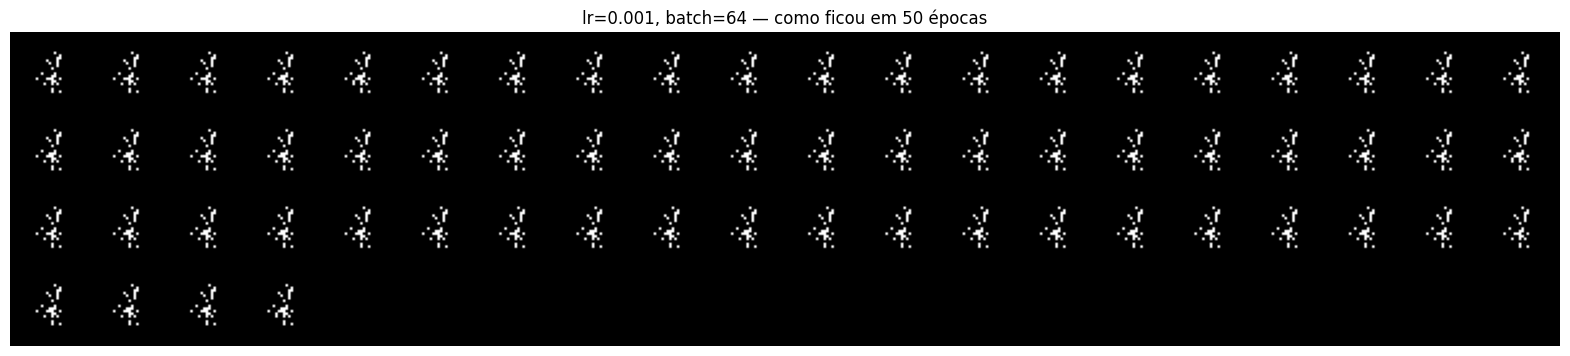

In [15]:
with torch.no_grad():
    test_z = torch.randn(batch_size_ac2, z_dim).to(device)
    generated_ac2 = G2(test_z)

generated_ac2 = generated_ac2.view(generated_ac2.size(0), 1, 28, 28)
grid_ac2 = torchvision.utils.make_grid(generated_ac2.cpu(), 20)
grid_ac2 = grid_ac2.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.title(f'lr={lr_ac2}, batch={batch_size_ac2} — como ficou em 50 épocas')
plt.imshow(grid_ac2.squeeze(), cmap='gray')
plt.axis('off')
plt.show()


### Conclusão

O treinamento da GAN por 50 épocas com `lr=0.001` e `batch_size=64` não produziu 
resultados satisfatórios. As imagens geradas não apresentam estrutura reconhecível 
de dígitos — o modelo claramente não convergiu.